In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
train_df = pd.read_csv('./content/train.csv')

In [33]:
train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


# Проверка null-значений

In [64]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Всего 708 сэмплов. Из них у 177 неизвестен возраст, который является важной фичёй для построения модели. Надо постараться будет заполнить данные значения.

# Проверка общего числа выживших

In [51]:
train_df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

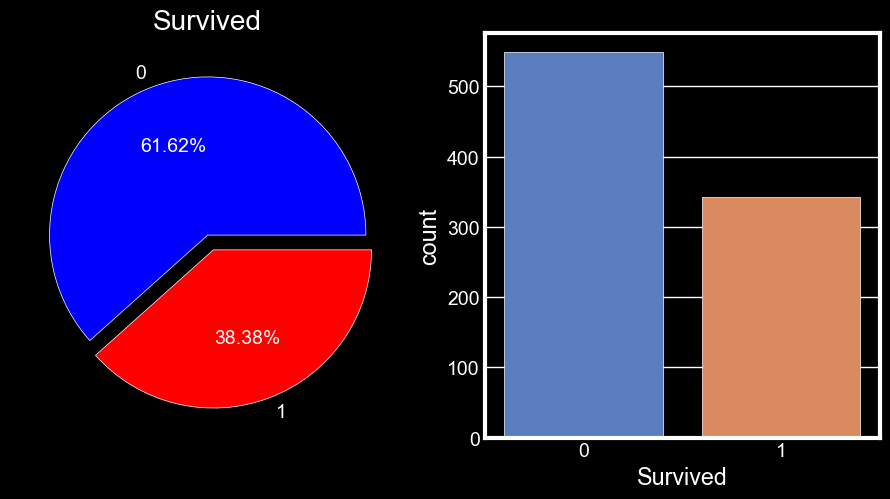

In [61]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
axes[0].pie(x=train_df['Survived'].value_counts(),
                labels=train_df['Survived'].unique(),
                autopct='%.2f%%',
                explode=(0, 0.1),
                colors=['blue', 'red'])
axes[0].set_title('Survived')
sns.countplot(data=train_df, x='Survived', palette='muted', ax=axes[1])
plt.show()

Получили общие сведения об количестве выживших и погибших. Большинство людей погибло. Данная статистика подтверждает факт о плохой подготовке экипажа к спасательной операции.

Предположу, на тестовой выборке модели должны будут предсказать большинство людей как погибших.

# Анализ фичей

Какие вообще есть признаки?

In [66]:
pd.DataFrame(train_df.columns)

,0
0,PassengerId
1,Survived
2,Pclass
3,Name
4,Sex
5,Age
6,SibSp
7,Parch
8,Ticket
9,Fare


Фичи *PassengerId*, *Name*, *Ticket* являются уникальными для каждого пассажира и не несут в себе информации о вероятности спасения. Их можно не анализировать, а после вообще избавиться.

Самыми интересными признаками являтюся *Sex* и *Age*. Начну с них, а дальше уже проверю оставшиеся.

## Анализ фичи *Sex*

Мы знаем количество спасшихся и погибших пассажиров. Разделим их по полу и посмотрим результаты:

In [92]:
train_df.groupby(['Survived', 'Sex']).count()['PassengerId']

Survived  Sex   
0         female     81
          male      468
1         female    233
          male      109
Name: PassengerId, dtype: int64

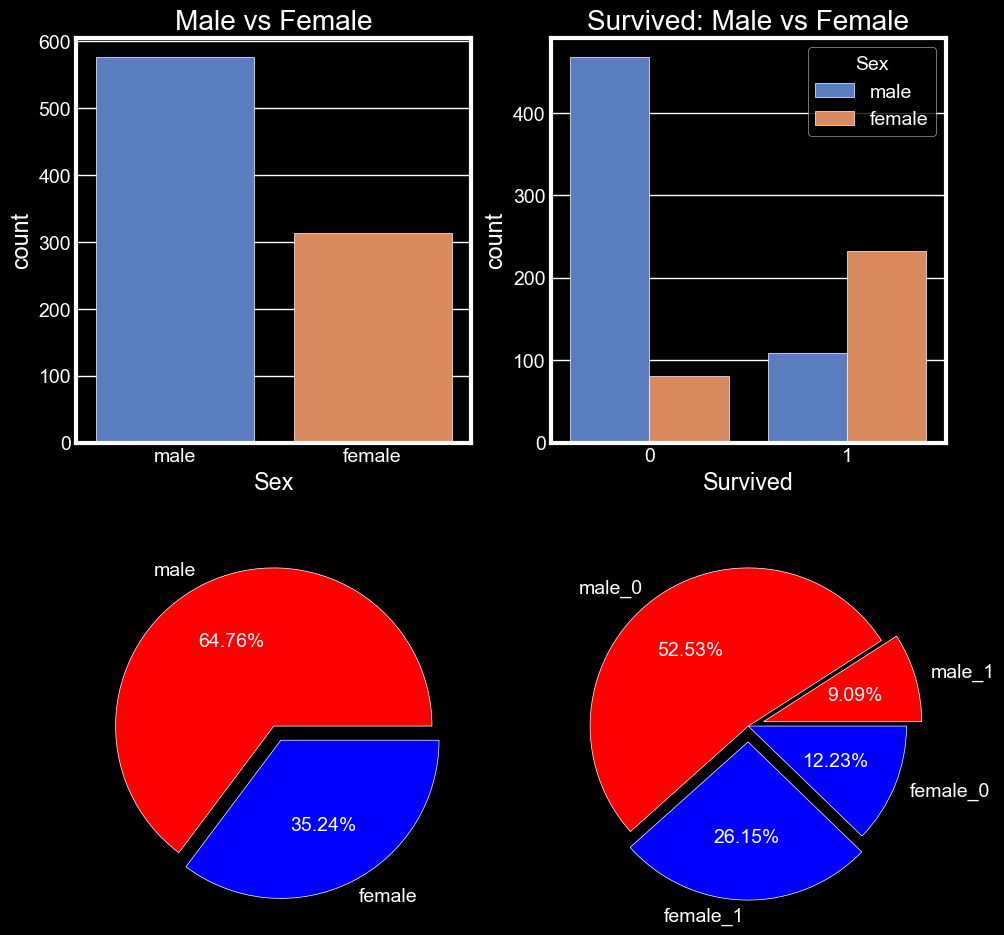

In [104]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 11))

sns.countplot(data=train_df, x='Sex', palette='muted', ax=axes[0, 0])
axes[0, 0].set_title('Male vs Female')

axes[1, 0].pie(x=train_df['Sex'].value_counts(),
               labels=train_df['Sex'].unique(),
               autopct='%.2f%%',
               explode=(0, 0.1),
               colors=['red', 'blue'])

sns.countplot(data=train_df, x='Survived', hue='Sex', palette='muted', ax=axes[0, 1])
axes[0, 1].set_title('Survived: Male vs Female')

axes[1, 1].pie(x=train_df.groupby(['Survived', 'Sex']).count()['PassengerId'],
               labels=['male_1', 'male_0', 'female_1', 'female_0'],
               autopct='%.2f%%',
               explode=(0.1, 0, 0.1, 0),
               colors=['red', 'red', 'blue', 'blue'])

plt.show()

На графиках видно, что на корабле мужчин было почти в 2 раза больше. Но при это в итоге женщин спаслось почти в 3 раза больше.

Из данной фичи можно сделать вывод, что спасение женщин было в сильном приоритете.

## Анализ фичи *Age* (also *Age+Sex*)

Для начала узнаем минимальные, максимальные и средние возраста на корабле:

In [138]:
print(f'Min age is {train_df['Age'].min()} \nMax age is {train_df['Age'].max()} \nMean age is {train_df['Age'].mean()}')

Min age is 0.42 
Max age is 80.0 
Mean age is 29.69911764705882


Построим гистограмму для распределения возрастов на корабле и гистограмму для распределения возрастов спавшихся пассажиров:

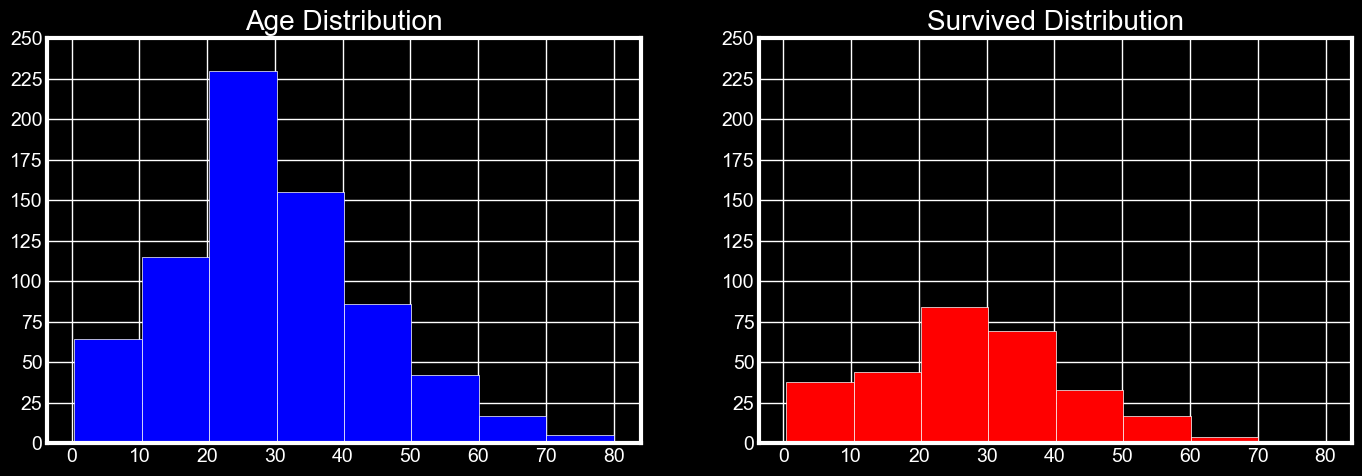

In [162]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axes[0].hist(x=train_df['Age'],
             bins=8,
             color='blue')
axes[0].set_xticks(np.arange(0, 81, 10))
axes[0].set_yticks(np.arange(0, 251, 25))
axes[0].set_title('Age Distribution')

axes[1].hist(x=train_df[train_df['Survived'] == 1]['Age'],
             bins = 8,
             color='red')
axes[1].set_xticks(np.arange(0, 81, 10))
axes[1].set_yticks(np.arange(0, 251, 25))
axes[1].set_title('Survived Distribution')

plt.show()

Как вы видим, на корабле преобладала молодёжь — люди в возрасте от 20 до 30.\
Среди выживших тоже преобладает молодёжь. Можно предположить, что приоритет в спасении отдавался людям в возрасте от 20 до 30 лет. Однако видно, что среди 225+ молодёжи выжило только около 80, хотя среди 60 детей выжило 40+.

Стоит посмотреть на среднюю вероятность спасения той или иной возрастной группы.\
Для этого преобразуем непрерывную величину возраст в дискретную:

In [3]:
train_df['Age_Group'] = pd.cut(x=train_df['Age'],
       bins=[0, 10.01, 20.01, 30.01, 40.01, 50.01, 60.01, 70.01, 80.01],
       labels=[0, 1, 2, 3, 4, 5, 6, 7])
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,3
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,3
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,2
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,2


Посмотрим на количество выживших в каждой возрастной группе:

In [242]:
pd.crosstab(train_df['Age_Group'], train_df['Survived']).style.background_gradient(cmap='Blues')

Survived,0,1
Age_Group,,
0,26,38
1,71,44
2,146,84
3,86,69
4,53,33
5,25,17
6,13,4
7,4,1


Судя по отношению спасшихся к погибшим в каждой группе, приоритет отдавался детям.

Посчитаем вероятность выживания в каждой группе:

In [243]:
train_df.groupby('Age_Group')['Survived'].mean()

Age_Group
0    0.593750
1    0.382609
2    0.365217
3    0.445161
4    0.383721
5    0.404762
6    0.235294
7    0.200000
Name: Survived, dtype: float64

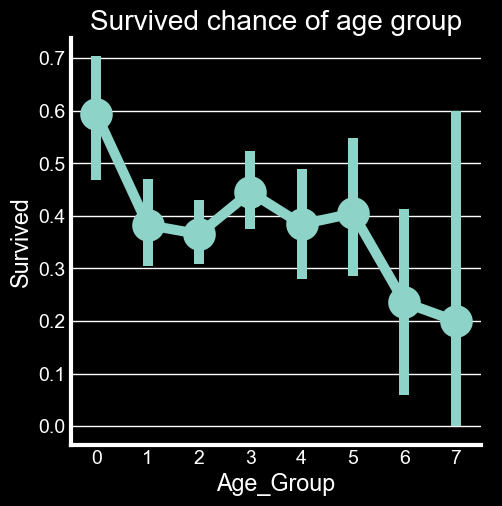

In [283]:
sns.catplot(data=train_df, x='Age_Group', y='Survived', kind='point')
plt.title('Survived chance of age group')
plt.show()

Как видно, самая большая вероятность выживания у детей от 0 до 10 лет. Если не считать детей, самая большая вероятность выживания у группы 30-40 лет.

Я бы охарактеризовал это тем, что самый большой преоритет спасения отдавался детям. После них приоритет отдавался группе 30-40 лет.\
Предположу, что в данной группе находился самый богатый класс пассажиров и их спутниц, отчего так сильно вырастает вероятность выживания.

Теперь в каждой группе разделим людей по полу и посмотрим количество выживших:

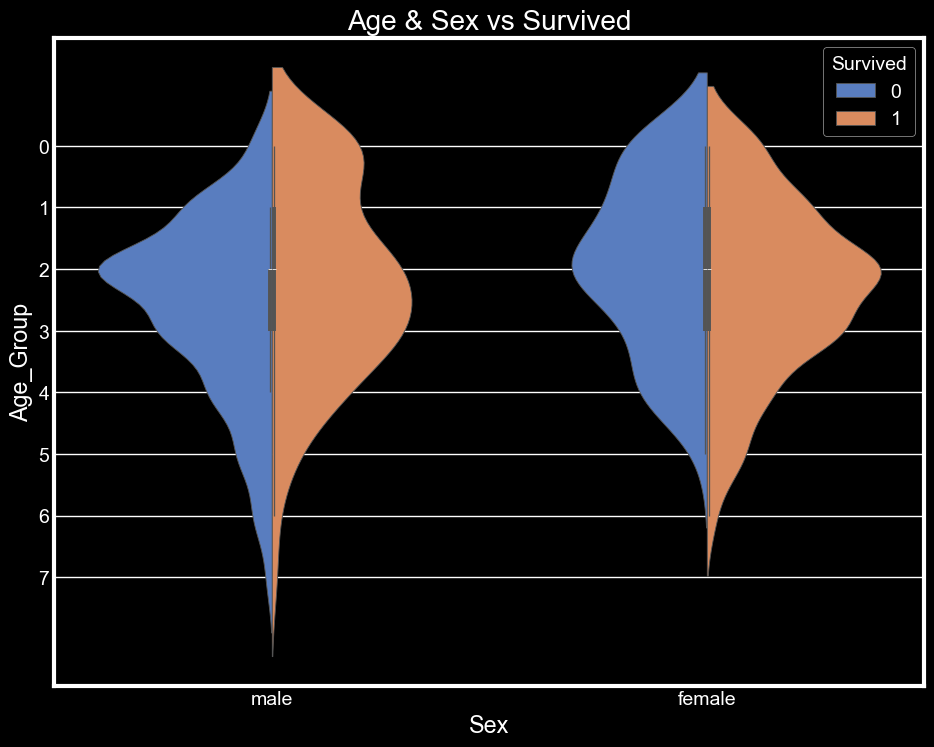

In [263]:
plt.figure(figsize=(10, 8))
sns.violinplot(data=train_df, x='Sex', y='Age_Group', hue='Survived', palette='muted', split=True)
plt.title("Age & Sex vs Survived")
plt.yticks(np.arange(0, 8))
plt.show()

Из графика видно, что среди детей больше всего выживших среди детей мужского пола. Спишу это на то, что у всех детей был одинаковой приоритет независимо от пола, а т.к. мужчин было почти в 3 раза больше на корабле, то и мальчиков спаслось больше.

Далее видно, что среди женщин большая выживаемость в категории 20-30 лет, а у мужчин — 20-40 лет. Останусь при мнение, что сегмент мужчин на корабле 20-40 лет был самым богатым и влиятельным, поэтому им отдавался приоритет. А девушки 20-30 были спустницами богатых и влиятельных мужчин + женщина отдавался приоритет при спасении, поэтому в данной категории больше всего спасшихся женщин.

## Анализ фичи *Pclass*

Данная фича говорит о том, каким классом ехал пассажир. Есть всего 3 класса: 1, 2, 3. Класс 1 — самый лучший и дорогой, 3 — самый худший и дешёвый.

Посмотрим сколько всего людей было в каждом классе:

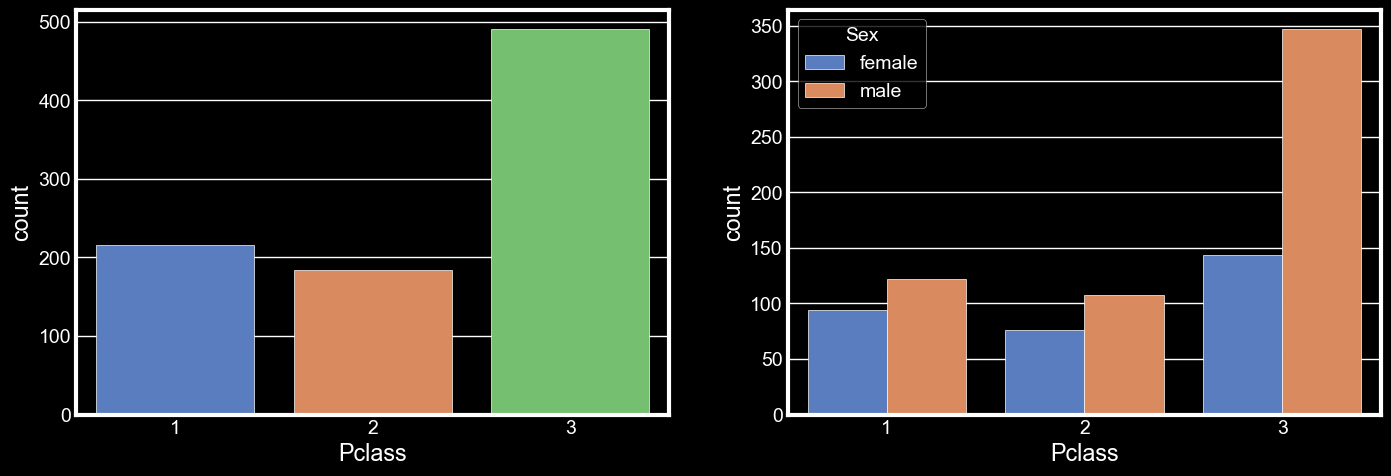

In [270]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

sns.countplot(data=train_df, x='Pclass', palette='muted', ax=axes[0])
sns.countplot(data=train_df, x='Pclass', hue='Sex', palette='muted', ax=axes[1])

plt.show()

Уже вижу, что если грубо округлять, в классах 1 и 2 мужчин и женщин было поровну, а в классе 3 мужчин было больше в >2 раза.\
Учитывая то, что при спасении отдавался приоритет детям, женщинам и состоятельным пассажирам, становится понятно почему так мало выживших среди мужчин — больше половины из них находились в 3-м классе.

 Глянем на количество выживших в каждом классе:

In [297]:
pd.crosstab([train_df['Pclass'], train_df['Sex']], train_df['Survived']).style.background_gradient(cmap='Blues')

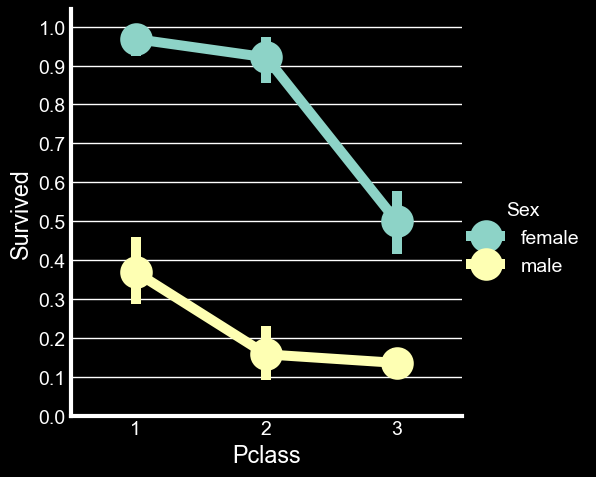

In [284]:
sns.catplot(data=train_df, x='Pclass', y='Survived', hue='Sex', kind='point')
plt.yticks(np.arange(0, 1.01, 0.1))
plt.show()

Видно, что у женщин в классах 1 и 2 вероятность выжить практически равна 1. У женщина из класса 3 шансы значительно меньше, чем у жинщин из классов 1 и 2, но по прежнему больше 0.5 и выше чем у мужчин.\
У мужчин всё заметно хуже: у самого лучшего класса вероятность выжить меньше 0.5, а у остальных классов вообще 0.1 (т.е. практически шансов нет).

Из этого можно сделать вывод, предположенный раньше — приоритет отдавался женщинам и богатым людям.

Добавим в подобный график возраст и посмотрим как изменится вероятнсоть выживания:

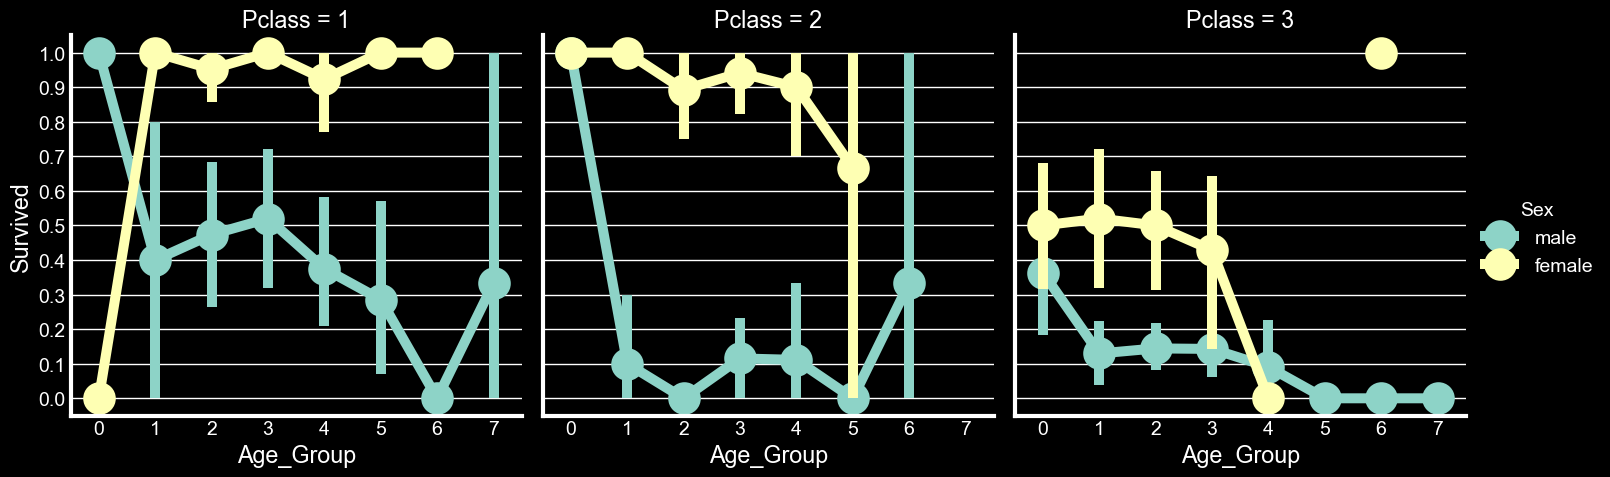

In [286]:
sns.catplot(data=train_df, x='Age_Group', y='Survived', hue='Sex', col='Pclass', kind='point')
plt.yticks(np.arange(0, 1.01, 0.1))
plt.show()

Вижу в классе 1 девочку (девочек) 0-10 лет, которые погибли в катастрофе. Похоже на выброс, ибо детям отдавался высший приоритет. Возможно в суматохе и невнимательности не заметили данного пассажира, из-за чего так и получилось. Возможно стоит почистить данные от данного выброса.

Видно, что в классе 3 идёт разрыв в *Age_Group* = 5. Похоже, сэмплы из данной категории отсутствуют либо обозначенны как NaN. Стоит поработать над null-значениями и заполнить их.

А так в общем и целом видна тенденция: детям отдаётся высший приоритет, затем идут женщины, после них мужчины. Параллельно с этим работает приоритет по финансовому положении. Стоит обратить внимание, что в классах 1 и 2 у детей вероятность спастись была 1 (не считая выбор), в то время как в классе 3 — вероятность меньше 0.5. Возможно у детей вообще была бы вероятность спастись 1, если бы не влияло финансовое положение и не было выборосов.

## Анализ фичей *SibSp*

Признак *SibSp* показывает количество братьев, сестёр и супругов на корабле.

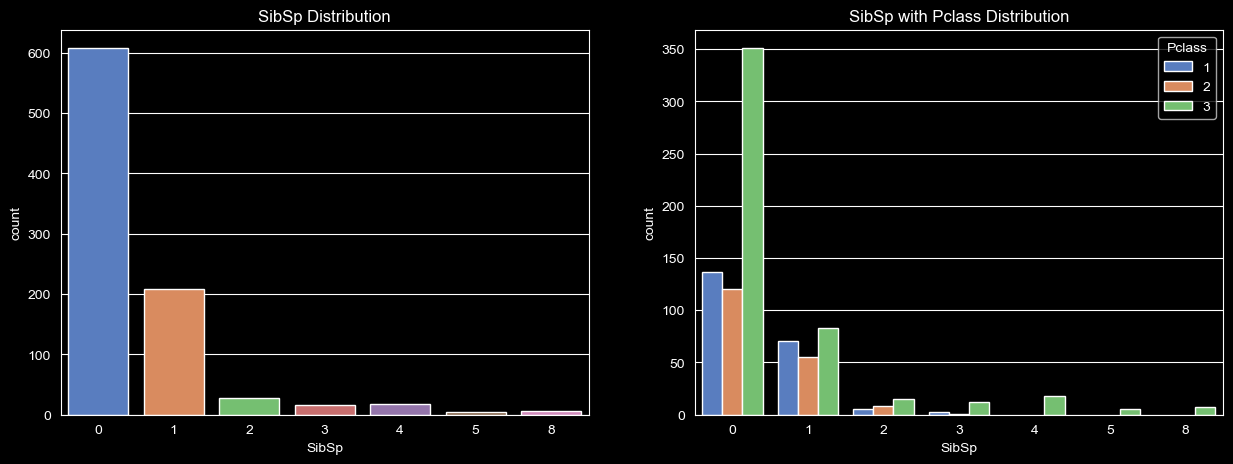

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

sns.countplot(data=train_df, x='SibSp', palette='muted', ax=axes[0])
axes[0].set_title('SibSp Distribution')

sns.countplot(data=train_df, x='SibSp', hue='Pclass', palette='muted', ax=axes[1])
axes[1].set_title('SibSp with Pclass Distribution')

plt.show()

Видим, что на корабле больше всего было людей без братье, сестёр и супругов. Также достаточно много было людей с 1 братом / сестрой / супругом. Логично предположить, что это был супруг.\
Дальше количество таких людей очень мало.

На 2-ом графике видно, что большинство одиночек было в 3-м классе. Это сильно повлияло на их вероятность выживания на корабле. Но и 1-м и 2-м классами плыло очень много одиночек. Возможно эти люди были с родителями / детьми или с любовницами / женихами, которые не учитывались в данном столбце.\
Людей с 1-м братом / сестрой / супругом на корабле было, грубо говоря, поровку во всех классах.\
А вот во всех остальных категориях преобладал 3-ий класс. Т.е. люди, которые плыли большими семьями на корабле, находились в основном в 3-м классе. А т.к. 3-ему классу отдавался самый низкий приоритет при спасении, логично предположить, что выживание среди них было мало. Ещё и сыграл фактор родственных чувств: при такой катастрофе у тебя будет желание спасти семью, а не самого себя, поэтому это ещё понижает шансы на выживание.

Посмотрим на вероятность выживания каждого из них:

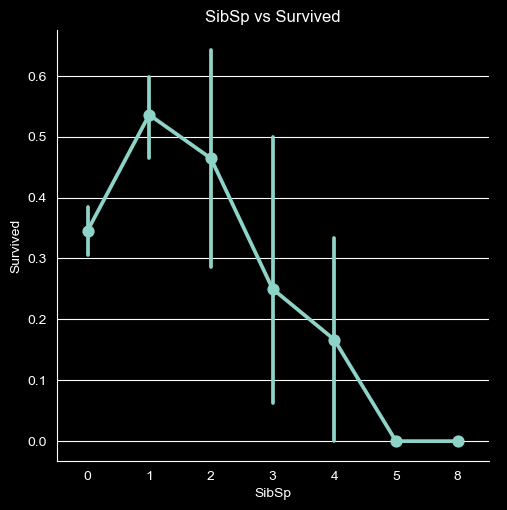

In [126]:
sns.catplot(data=train_df, x='SibSp', y='Survived', kind='point')
plt.title('SibSp vs Survived')
plt.show()

Видно, что более всего вероятность спастись у малым количеством братьев / сестёр / супругов. Самая большая у тех, что едет в паре.\
У семей с количество братьев / сестёр / супругов >2 шансы спастись очень малы. Напомню, такие семье практически все были в классе 3, у которого итак шансы спастись были малы.

Взглянем на этот же график, разделив на *Pclass*:

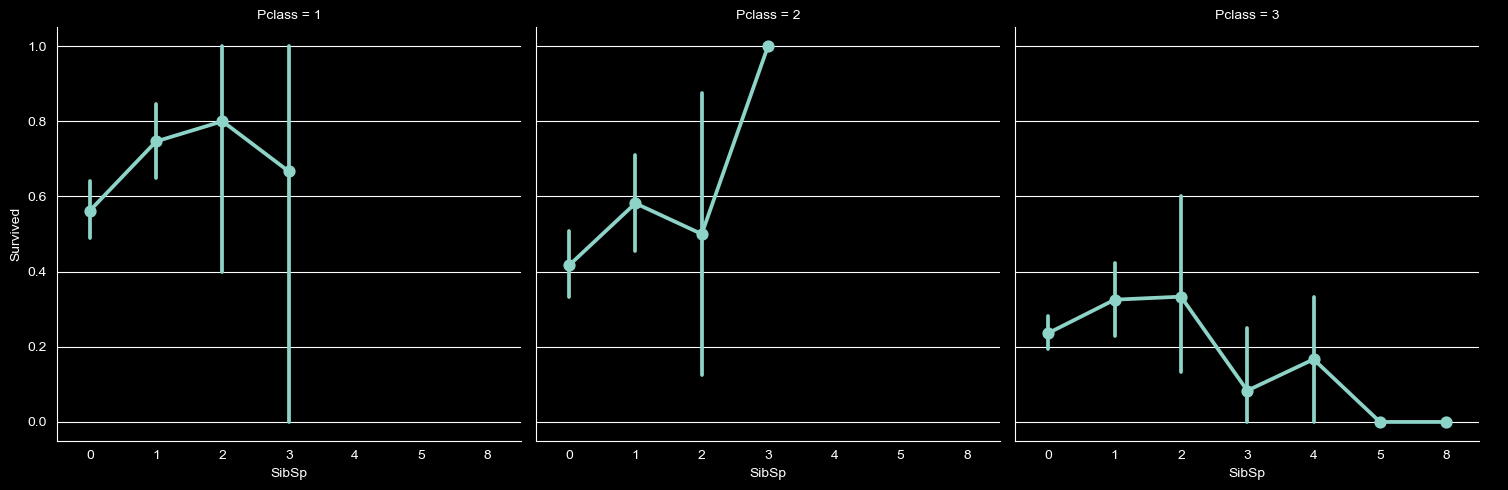

In [32]:
sns.catplot(data=train_df, x='SibSp', y='Survived', col='Pclass', kind='point')
plt.show()

Видно, что у всех семей, которые ехали классом 1, вероятность выжить достаточно большая.\
Семьи, которые ехали классом 2, выжили с меньшей вероятность. но при этом она всё равно немаленькая. Если глянуть на *Pclass* = 2 и *SibSp* = 3, можно увидеть, что там вероятность спасения вообще 1. Видимо, там была одна семья, которой повезло. Такая же статистика присутствует и в *Pclass* = 3 и *SibSp* = 4. Но при этом в классе 3 больше всего было больших семей. Предположу, выжить удалось нескольким людям из *Pclass* = 3 и *SibSp* = 4. Опять всё спишу на совпадение, ибо вряд-ли в подобной ситуации обращали внимание на большие семьи из класса 3.

In [34]:
pd.crosstab(index=train_df['SibSp'], columns=train_df['Survived']).style.background_gradient(cmap='Blues')

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


Таблица *crosstab* не привнесла ничего нового. Возможно стоить обратить внимание, что людям с *SibSp* >= 5 нет абсолютно никаких шансов на выживание.

Стоит ещё проанализировать связь между *SibSp* и *Age*. Если обратить внимание, к *SibSp* относятся братья / сёстры / супруги — т.е. это все родственники из одного поколения. Если, например, у человека с *SibSp* = 5 возраст 40, то и у всех его братьев / сестёр / супруга возраст будет примерно одинаковый:

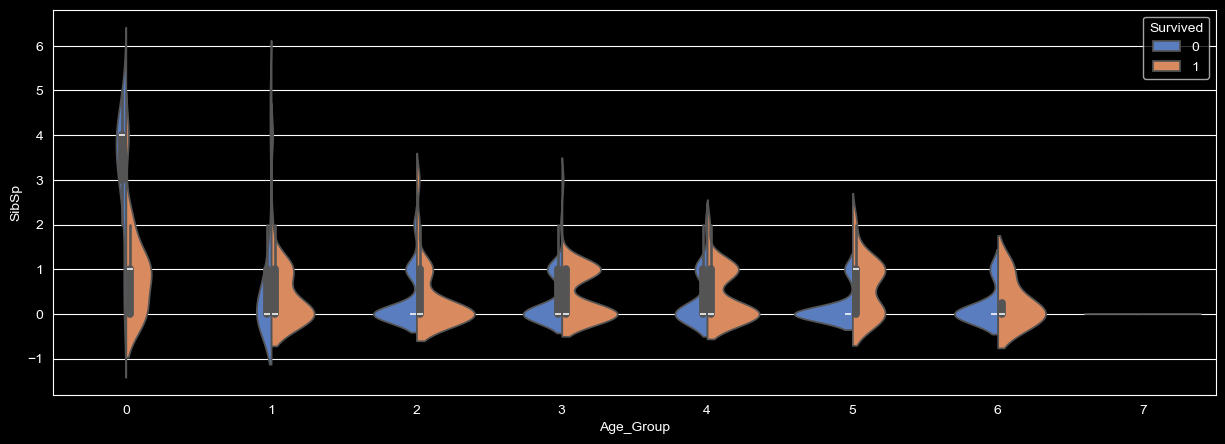

In [44]:
plt.figure(figsize=(15, 5))
sns.violinplot(data=train_df, x='Age_Group', y='SibSp', hue='Survived', split=True, palette='muted')
plt.show()

Несколько наблюдей по графику выше:
- У детей, у которых не было братьев и сестёр, либо если был только 1, вероятность выжить высока;
- Во всех возрастных группах при *SibSp* >=2 шансы выжить очень малы;
- У группы 50-60 лет шансы выжить достаточно хорошие, если они ехали без или с одним братом / сестрой / супругом;
- У группы 60-70 лет большие шансы на выживание, когда они плывут без братьев / сестёр / супругов;
- У групп 10-50 лет самый большие шансы на выживание в одиночку.

## Анализ фичи *Parch*

Данный признак показывает количество родителей и детей на корабле.

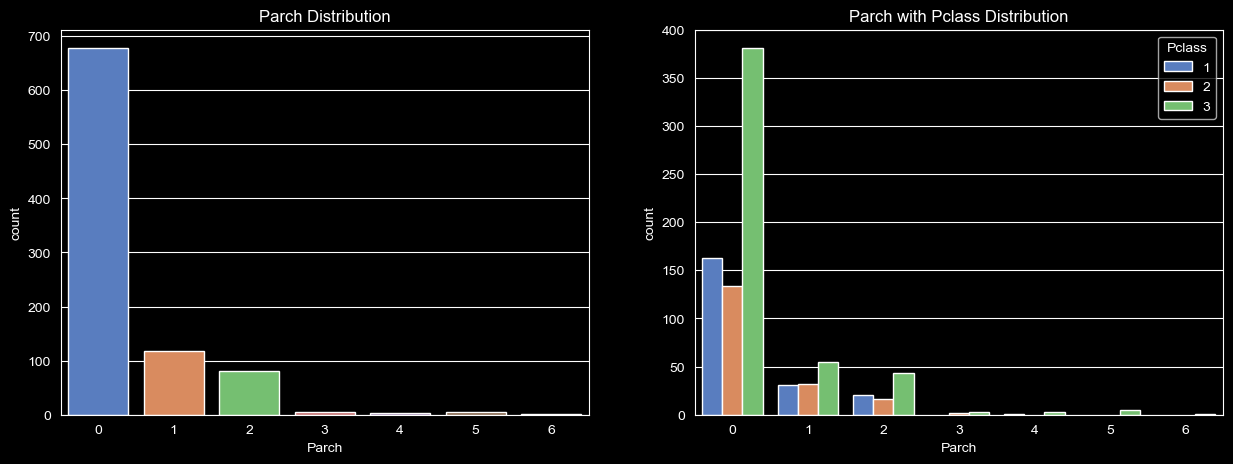

In [46]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

sns.countplot(data=train_df, x='Parch', palette='muted', ax=axes[0])
axes[0].set_title('Parch Distribution')

sns.countplot(data=train_df, x='Parch', hue='Pclass', palette='muted', ax=axes[1])
axes[1].set_title('Parch with Pclass Distribution')

plt.show()

Больше всего людей было без родителей и детей. Таких людей больше всего было в 3-м классе. Но и в 1-м и 2-м классе много было людей без родителей и детей.\
Многодетных семей (*Parch* >= 3) больше всего было в 3-м классе, у которого шансы на выживание очень малы.

Глянем на вероятность выживания при различном *Parch*:

In [47]:
pd.crosstab(index=train_df['Parch'], columns=train_df['Survived']).style.background_gradient('Blues')

Survived,0,1
Parch,,
0,445,233
1,53,65
2,40,40
3,2,3
4,4,0
5,4,1
6,1,0


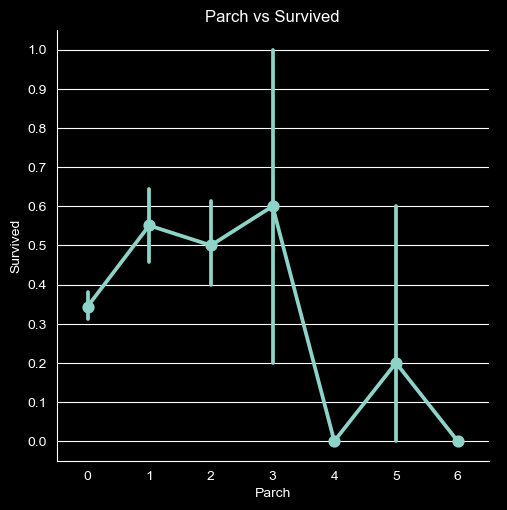

In [125]:
sns.catplot(data=train_df, x='Parch', y='Survived', kind='point')
plt.yticks(np.arange(0, 1.01, 0.1))
plt.title('Parch vs Survived')
plt.show()

Видно хорошие шансы на выживание при *Parch* от 1 до 3 включительно. Во всех остальных вероятность меньше половины.

Также видно, что у *Parch* = 5 есть хоть какие-то шансы на выживание. Возможно кому-то одному получилось так спастись. Взглянем на него:

In [54]:
train_df[(train_df['Parch'] == 5) & (train_df['Survived'] == 1)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Group
25,26,1,3,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,1,5,347077,31.3875,NaN,S,3


Интересно: это женщина средних лет из класса 3, которая, скорее всего, ехала с супругом и 5-ю детьми. У него удалось спастись, хотя шансы на спасение у класса 3 очень малы. Интересно, получилось ли спастись у её остальной семьи:

In [66]:
train_df[train_df['Name'].str.contains('.*Asplund.*', regex=True)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Group
25,26,1,3,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,1,5,347077,31.3875,NaN,S,3
182,183,0,3,"Asplund, Master. Clarence Gustaf Hugo",male,9.0,4,2,347077,31.3875,NaN,S,0
233,234,1,3,"Asplund, Miss. Lillian Gertrud",female,5.0,4,2,347077,31.3875,NaN,S,0
261,262,1,3,"Asplund, Master. Edvin Rojj Felix",male,3.0,4,2,347077,31.3875,NaN,S,0


Был осуществлён поиск родственников данной женщины. Удалось только узнать её детей. Тот самый *SibSp*, который ехал с ней, возможно имеет другую фамилию и его тяжело найти.\
Остальные 2 человек из *Parch* не указаны как дети, возможно, это её родители также с другой фамилией.

Предположу: данной женщине удалось выжить за счёт детей, ибо выживание детей без родителей почти не имеет смысла, поэтому ей было позволено спуститься на спасательную шлюпку вместе с детьми.

## Анализ фичи *Fare*

*Fare* показывает стоимость проезда пассажира.

Посмотрим сколько стоят билеты:

In [78]:
print(f'Min fare is {train_df["Fare"].min()} \nMax fare is {train_df["Fare"].max()} \nMean fare is {train_df["Fare"].mean()}')

Min fare is 0.0 
Max fare is 512.3292 
Mean fare is 32.204207968574636


Хмм, интересное наблюдение — самый дешёвый билет стоит 0$, т.е. бесплатный. Глянем на данные сэмплы подробнее:

In [79]:
train_df[train_df['Fare'] == 0.0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Group
179,180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,NaN,S,3
263,264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,B94,S,3
271,272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S,2
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0,NaN,S,NaN
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S,1
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,239853,0.0,NaN,S,NaN
466,467,0,2,"Campbell, Mr. William",male,NaN,0,0,239853,0.0,NaN,S,NaN
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0,NaN,S,NaN
597,598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,NaN,S,4
633,634,0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0,NaN,S,NaN


Наблюдения по бесплатным билетам:
- Билеты выдавались на все классы;
- По бесплатным билетам поплыли только мужчины;
- Бесплатные билеты выдавались всем классам, но выжить удалось только у человека из класса 3 :)
- Все эти люди были без родственников (*SibSp* и *Parch*), т.е. плыли в одиночестве;
- Все сели на судно в порту S — самый первый порт, где село большинство пассажиров.

Можно предположить, что билеты были выигрышными или что-то в этом роде, поэтому люди ехали одни и садились в самом первом порту.

Хорошо, пойдём дальше:

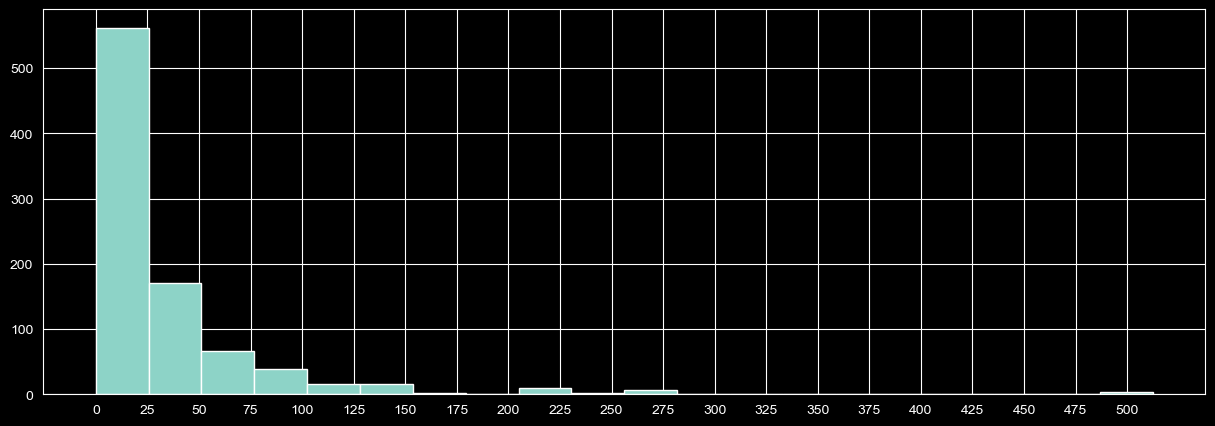

In [76]:
plt.figure(figsize=(15, 5))
plt.hist(train_df['Fare'], bins=20)
plt.xticks(np.arange(0, 501, 25))
plt.show()

Видно, что большинство билетов было от 0\\$ до 50\\$, а самые дороги стоили около 500\\$. Это также видно по тому, что большинство людей находилось в классе 3.

В среднем билеты стоят 32\\$.

Посмотрим на цены билетов для каждого класса:

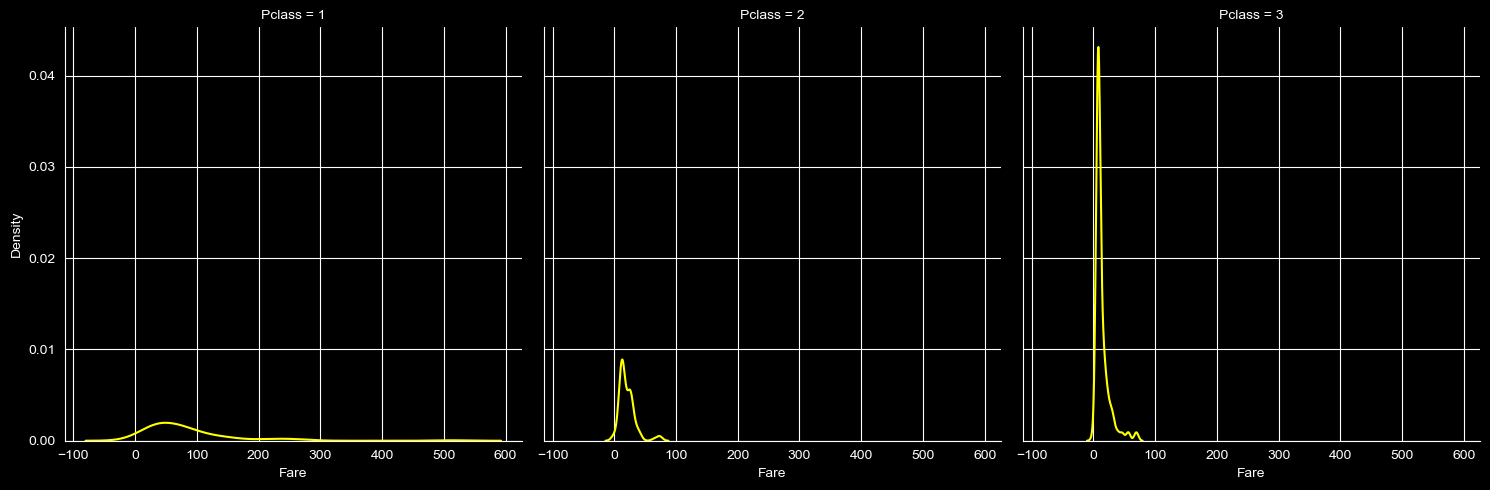

In [121]:
sns.displot(data=train_df, x='Fare', col='Pclass', kind='kde', color='yellow', ax=axes[2])
plt.show()

Видно, что в 1-м классе преобладают билеты из диапазона от 0\\$ до 100$, но также и присутствуют билеты и до 500\\$. А вот в класса 2 и 3 большинство билетов за цену <50\\$, а билетов за 100\\$+ вообще нет.

## Анализ фичи *Embarked*

Данный признак показывает порт отправления пассажира. Всего 3 порта отправления: *S*, *C* и *Q*.

Посмотрим сколько людей зашло на судно с каждого порта:

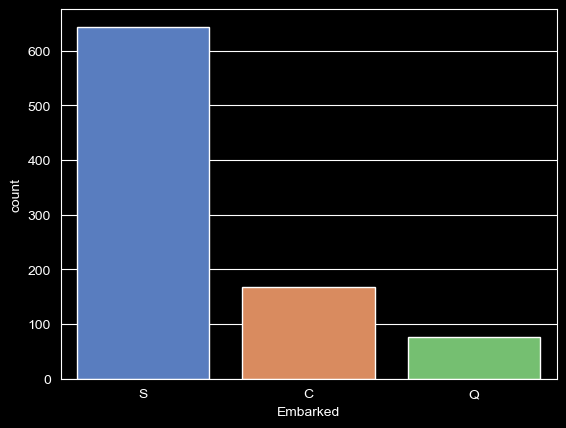

In [124]:
sns.countplot(data=train_df, x='Embarked', palette='muted')
plt.show()

Большинство пассажиров село в порту *S* — самый первый порт. Затем большая часть вошла на порту *C* — это второй порт, куда заплывал Титаник. И в последнем порту *Q* зашла оставшаяся небольшая часть пассажиров.

Посмотрим на вероятность выживания в зависимости от порта:

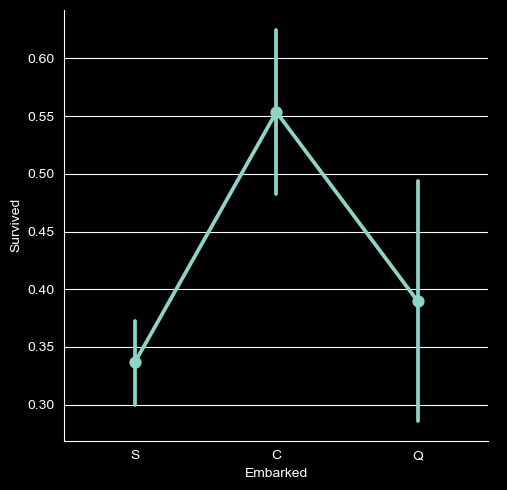

In [127]:
sns.catplot(data=train_df, x='Embarked', y='Survived', kind='point')
plt.show()

Больше всего шанс выжить у людей из порта *C*, у остальных они достаточно мало. Интересно, связано ли это как то с классом пассажира? Проверим:

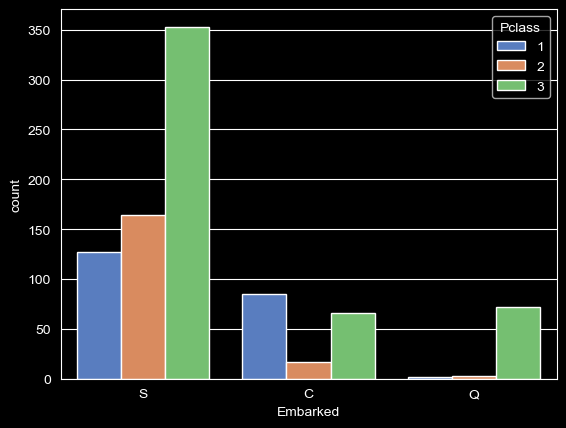

In [129]:
sns.countplot(data=train_df, x='Embarked', hue='Pclass', palette='muted')
plt.show()

Действительно, в порту *C* больше всего село людей в класс 1. А т.к. классу 1 отдавался высокий приоритет, то и шансы выжить были высоки.

В порту *S* село очень много людей из класса 3, поэтому шансы на выживания для этого порта достаточно малы.

Интересен факт, что в порту *Q* сели людям в основном из класса 3, но при этом шансы на выживания у людей больше, чем у людей из порта *S*.\
Предположу: повлиял тот факт, что в порту *S* село почти в 10 раз больше людей из класса 3, чем в порту *Q*, что и повлияло на шансы выживание, хоть и не сильно, ведь у людей из обоих портов шансы выжить всё равно малы.

## Проверка корреляции между признаками

Проверим корреляцию между изначальными признаками.\
Я уже добавил новый признал *Age_Group*, но его пока что не будем учитывать в корреляции.\
Корреляцию нельзя провести с категориальными и ординальными признаками. Т.к. я ещё никак не преобразовывал изначальные данные, не будем учитывать и их в данной корреляции:

In [134]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age_Group'],
      dtype='str')

In [142]:
train_df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']].corr().style.background_gradient(cmap='coolwarm').format("{:.2f}")

,Pclass,Age,SibSp,Parch,Fare,Survived
Pclass,1.00,-0.37,0.08,0.02,-0.55,-0.34
Age,-0.37,1.00,-0.31,-0.19,0.10,-0.08
SibSp,0.08,-0.31,1.00,0.41,0.16,-0.04
Parch,0.02,-0.19,0.41,1.00,0.22,0.08
Fare,-0.55,0.10,0.16,0.22,1.00,0.26
Survived,-0.34,-0.08,-0.04,0.08,0.26,1.00


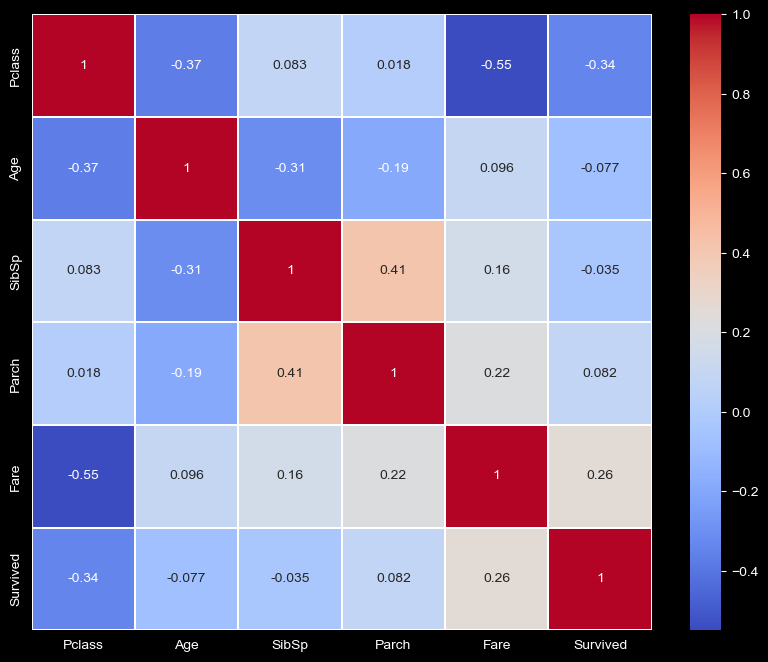

In [155]:
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']].corr(), annot=True, cmap='coolwarm', linewidths=0.2)
plt.show()

Видимо, что никакой корреляции между признаками нет. Виднеются какие-то числа между *Pclass* и *Fare* (логично: цена билета растёт, номер класса падает), но значение -0.55 не критично.